# 0. Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, label_binarize
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from scipy import stats
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Obtendo a informação de versões para o requirements.txt
!pip list | grep -E "pandas|numpy|matplotlib|seaborn|joblib|scikit-learn|imbalanced-learn|scipy"

geopandas                                1.1.1
imbalanced-learn                         0.14.0
joblib                                   1.5.2
matplotlib                               3.10.0
matplotlib-inline                        0.2.1
matplotlib-venn                          1.1.2
numpy                                    2.0.2
pandas                                   2.2.2
pandas-datareader                        0.10.0
pandas-gbq                               0.30.0
pandas-stubs                             2.2.2.240909
scikit-learn                             1.6.1
scipy                                    1.16.3
seaborn                                  0.13.2
sklearn-pandas                           2.2.0


# 1. Tratamento dos dados

In [6]:
# Subindo os dados
dados = pd.read_csv('Obesity.csv')

In [7]:
dados.head(3)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight


In [8]:
# Checando por valores nulos
dados.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [9]:
# Checando por duplicatas
dados.duplicated().sum()

np.int64(24)

In [10]:
# Removendo duplicatas
dados.drop_duplicates(inplace=True)

In [11]:
# Obtendo informações gerais sobre o dataset
dados.shape

(2087, 17)

In [12]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), object(9)
memory usage:

## 1.1 Arredondando números que deveriam ser inteiros

In [13]:
dados['FCVC'] = dados['FCVC'].round(0)

In [14]:
dados['NCP'] = dados['NCP'].round(0)

In [15]:
dados['CH2O'] = dados['CH2O'].round(0)

In [16]:
dados['FAF'] = dados['FAF'].round(0)

In [17]:
dados['TUE'] = dados['TUE'].round(0)

# 2. Análise Exploratória de Dados

In [18]:
# Obtendo informações avançadas sobre o dataset
dados.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.425970,2.703402,2.011500,1.009104,0.669861
std,6.368801,0.093186,26.190847,0.585177,0.797108,0.685322,0.898712,0.673970
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,3.000000,2.000000,0.000000,0.000000
50%,22.847618,1.701584,83.101100,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [19]:
dados.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity'],
      dtype='object')

## 2.1 Entendendo os valores únicos

In [20]:
dados['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [21]:
dados['Age'].unique()

array([21.      , 23.      , 27.      , ..., 22.524036, 24.361936,
       23.664709])

In [22]:
dados['Height'].unique()

array([1.62    , 1.52    , 1.8     , ..., 1.752206, 1.73945 , 1.738836])

In [23]:
dados['Weight'].unique()

array([ 64.      ,  56.      ,  77.      , ..., 133.689352, 133.346641,
       133.472641])

In [24]:
dados['family_history'].unique()

array(['yes', 'no'], dtype=object)

In [25]:
dados['FAVC'].unique()

array(['no', 'yes'], dtype=object)

In [26]:
dados['FCVC'].unique()

array([2., 3., 1.])

In [27]:
dados['NCP'].unique()

array([3., 1., 4., 2.])

In [28]:
dados['CAEC'].unique()

array(['Sometimes', 'Frequently', 'Always', 'no'], dtype=object)

In [29]:
dados['SMOKE'].unique()

array(['no', 'yes'], dtype=object)

In [30]:
dados['CH2O'].unique()

array([2., 3., 1.])

In [31]:
dados['SCC'].unique()

array(['no', 'yes'], dtype=object)

In [32]:
dados['FAF'].unique()

array([0., 3., 2., 1.])

In [33]:
dados['TUE'].unique()

array([1., 0., 2.])

In [34]:
dados['CALC'].unique()

array(['no', 'Sometimes', 'Frequently', 'Always'], dtype=object)

In [35]:
dados['MTRANS'].unique()

array(['Public_Transportation', 'Walking', 'Automobile', 'Motorbike',
       'Bike'], dtype=object)

In [36]:
dados['Obesity'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

## 2.2 Análise visual com Boxplots

<Axes: xlabel='Age'>

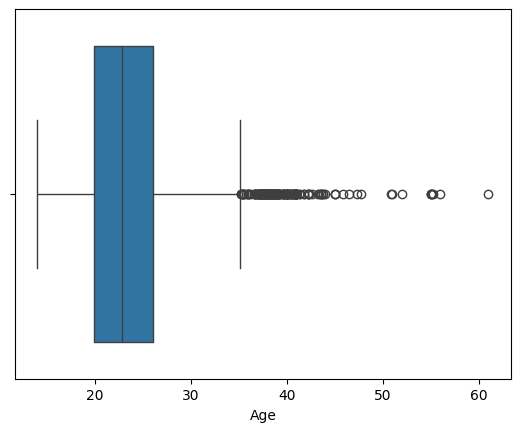

In [37]:
sns.boxplot(data=dados, x='Age')

<Axes: xlabel='Height'>

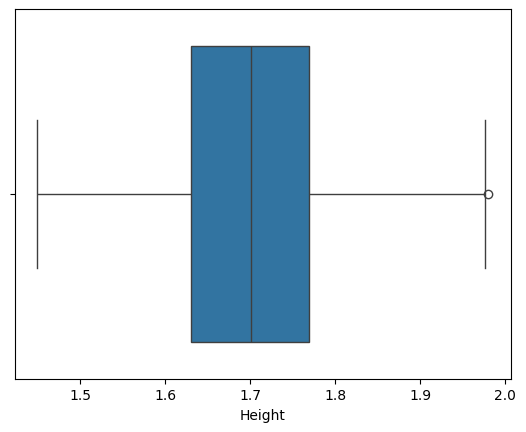

In [38]:
sns.boxplot(data=dados, x='Height')

<Axes: xlabel='Weight'>

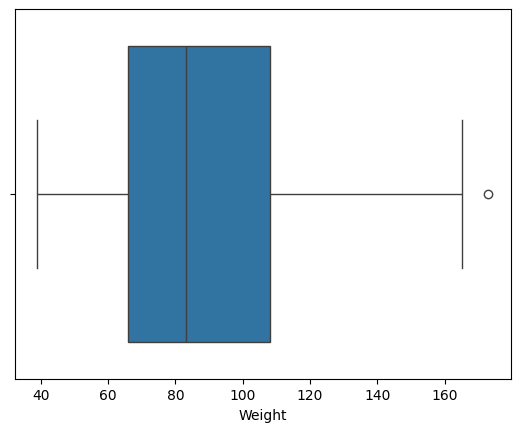

In [39]:
sns.boxplot(data=dados, x='Weight')

## 2.3 Análise das distribuições categóricas

In [40]:
def distribuicao (coluna):
  contagem = dados[coluna].value_counts()
  percentual = dados[coluna].value_counts(normalize=True)*100
  df = pd.DataFrame({
    'Contagem': contagem,
    'Percentual (%)': percentual
  })
  return df

In [41]:
distribuicao('Gender')

,Contagem,Percentual (%)
Gender,,
Male,1052,50.407283
Female,1035,49.592717


In [42]:
distribuicao('family_history')

,Contagem,Percentual (%)
family_history,,
yes,1722,82.510781
no,365,17.489219


In [43]:
distribuicao('FAVC')

,Contagem,Percentual (%)
FAVC,,
yes,1844,88.356493
no,243,11.643507


In [44]:
distribuicao('FCVC')

,Contagem,Percentual (%)
FCVC,,
2.0,994,47.628174
3.0,991,47.484427
1.0,102,4.887398


In [45]:
distribuicao('NCP')

,Contagem,Percentual (%)
NCP,,
3.0,1466,70.244370
1.0,296,14.183038
2.0,176,8.433158
4.0,149,7.139435


In [46]:
distribuicao('CAEC')

,Contagem,Percentual (%)
CAEC,,
Sometimes,1761,84.379492
Frequently,236,11.308098
Always,53,2.539530
no,37,1.772880


In [47]:
distribuicao('SMOKE')

,Contagem,Percentual (%)
SMOKE,,
no,2043,97.891711
yes,44,2.108289


In [48]:
distribuicao('CH2O')

,Contagem,Percentual (%)
CH2O,,
2.0,1107,53.042645
3.0,502,24.053666
1.0,478,22.903690


In [49]:
distribuicao('SCC')

,Contagem,Percentual (%)
SCC,,
no,1991,95.400096
yes,96,4.599904


In [50]:
distribuicao('FAF')

,Contagem,Percentual (%)
FAF,,
1.0,759,36.367992
0.0,714,34.211787
2.0,495,23.718256
3.0,119,5.701965


In [51]:
distribuicao('TUE')

,Contagem,Percentual (%)
TUE,,
0.0,932,44.657403
1.0,912,43.699090
2.0,243,11.643507


In [52]:
distribuicao('CALC')

,Contagem,Percentual (%)
CALC,,
Sometimes,1380,66.123622
no,636,30.474365
Frequently,70,3.354097
Always,1,0.047916


In [53]:
distribuicao('MTRANS')

,Contagem,Percentual (%)
MTRANS,,
Public_Transportation,1558,74.652611
Automobile,456,21.849545
Walking,55,2.635362
Motorbike,11,0.527072
Bike,7,0.335410


In [54]:
distribuicao('Obesity')

,Contagem,Percentual (%)
Obesity,,
Obesity_Type_I,351,16.818400
Obesity_Type_III,324,15.524677
Obesity_Type_II,297,14.230954
Overweight_Level_II,290,13.895544
Normal_Weight,282,13.512218
Overweight_Level_I,276,13.224724
Insufficient_Weight,267,12.793483


## 2.4 Análise visual com Histogramas

<Axes: xlabel='Age', ylabel='Count'>

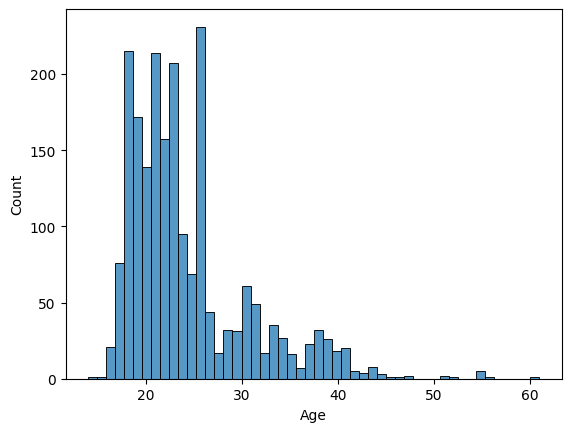

In [55]:
sns.histplot(data=dados, x='Age')

<Axes: xlabel='Height', ylabel='Count'>

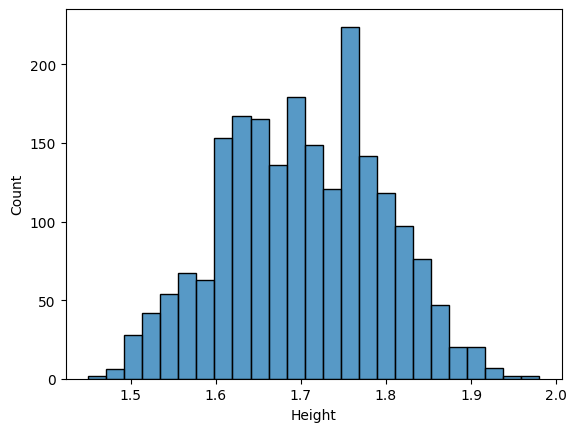

In [56]:
sns.histplot(data=dados, x='Height')

<Axes: xlabel='Weight', ylabel='Count'>

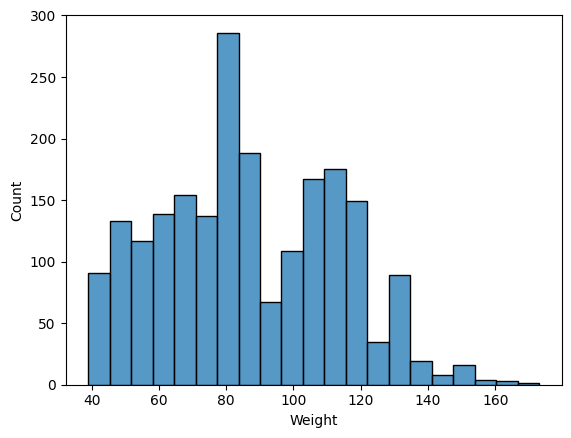

In [57]:
sns.histplot(data=dados, x='Weight')

# 3. Formatação do dataset para uso no Dashboard

In [58]:
dash = dados.copy()

In [59]:
dash.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [60]:
map_gender = {'Female': 'Feminino', 'Male': 'Masculino'}
map_family = {'yes': 'Sim', 'no': 'Não'}
map_favc = {'yes': 'Sim', 'no': 'Não'}
map_fcvc = {1:'Raramente', 2:'Às Vezes', 3:'Sempre'}
map_ncp = {1:'Uma', 2:'Duas', 3:'Três', 4:'Quatro ou mais' }
map_caec = {'no': 'Não', 'Sometimes': 'Às Vezes', 'Frequently':'Frequentemente', 'Always':'Sempre'}
map_smoke = {'yes': 'Sim', 'no': 'Não'}
map_ch20 = {1:'<1 L/dia', 2:'1-2 L/dia', 3:'> 2 L/dia'}
map_scc = {'yes': 'Sim', 'no': 'Não'}
map_faf = {0:'Nenhuma', 1:'1-2x/semana', 2:'3-4x/semana', 3:'5-7x/semana'}
map_tue = {0:'0-2h/dia', 1:'3-5h/dia', 2:'mais que 5h/dia'}
map_calc = {'no':'Não Bebe', 'Sometimes': 'Às Vezes', 'Frequently':'Frequentemente', 'Always':'Sempre'}
map_mtrans = {'Automobile': 'Carro', 'Motorbike':'Moto', 'Bike':'Bicicleta',
              'Public_Transportation':'Transporte Público', 'Walking':'A pé'}
map_obesity = {'Insufficient_Weight': 'Abaixo do Peso', 'Normal_Weight':'Peso Normal',
               'Overweight_Level_I':'Sobrepeso I', 'Overweight_Level_II':'Sobrepeso II',
               'Obesity_Type_I':'Obesidade I', 'Obesity_Type_II':'Obesidade II',
               'Obesity_Type_III':'Obesidade III'}

In [61]:
dash = dash.assign(
    Gender=dash['Gender'].map(map_gender),
    family_history=dash['family_history'].map(map_family),
    FAVC=dash['FAVC'].map(map_favc),
    FCVC=dash['FCVC'].map(map_fcvc),
    NCP=dash['NCP'].map(map_ncp),
    CAEC=dash['CAEC'].map(map_caec),
    SMOKE=dash['SMOKE'].map(map_smoke),
    CH2O=dash['CH2O'].map(map_ch20),
    SCC=dash['SCC'].map(map_scc),
    FAF=dash['FAF'].map(map_faf),
    TUE=dash['TUE'].map(map_tue),
    CALC=dash['CALC'].map(map_calc),
    MTRANS=dash['MTRANS'].map(map_mtrans),
    Obesity=dash['Obesity'].map(map_obesity)
)

In [62]:
df_clean = dash.copy()
df_clean.to_csv('df_clean.csv', index=False)

In [63]:
titulos = ['Gênero', 'Idade', 'Altura', 'Peso', 'Histórico Familiar', 'Consumo de comidas calóricas',
           'Consumo de vegetais', 'Número de refeições', 'Come entre refeições?', 'Fuma?',
           'Consumo de água', 'Monitora calorias?', 'Atividade física',
           'Tempo em dispositivos eletrônicos', 'Consumo de álcool', 'Modal de transporte',
           'Nível de obesidade']

In [64]:
dash.columns = titulos

In [65]:
dash.to_csv('dash.csv', index=False)

# 4. Feature Engineering

## 4.1 Analisando correlações entre as variáveis

In [ ]:
feature = dados.copy()

In [ ]:
# Transformando valores em números para análise de correlação
map_gender = {'Female': 0, 'Male': 1}
map_family = {'yes': 1, 'no': 0}
map_favc = {'yes': 1, 'no': 0}
map_caec = {'no': 0, 'Sometimes': 1, 'Frequently':2, 'Always':3}
map_smoke = {'yes': 1, 'no': 0}
map_scc = {'yes': 1, 'no': 0}
map_calc = {'no':0, 'Sometimes': 1, 'Frequently':2, 'Always':3}
map_mtrans = {'Automobile': 1, 'Motorbike':2, 'Bike':3,
              'Public_Transportation':4, 'Walking':5}
map_obesity = {'Insufficient_Weight': 1, 'Normal_Weight':2, 'Overweight_Level_I':3,
               'Overweight_Level_II':4, 'Obesity_Type_I':5, 'Obesity_Type_II':6, 'Obesity_Type_III':7}

In [ ]:
feature = feature.assign(
    Gender=feature['Gender'].map(map_gender),
    family_history=feature['family_history'].map(map_family),
    FAVC=feature['FAVC'].map(map_favc),
    CAEC=feature['CAEC'].map(map_caec),
    SMOKE=feature['SMOKE'].map(map_smoke),
    SCC=feature['SCC'].map(map_scc),
    CALC=feature['CALC'].map(map_calc),
    MTRANS=feature['MTRANS'].map(map_mtrans),
    Obesity=feature['Obesity'].map(map_obesity)
)

<Axes: >

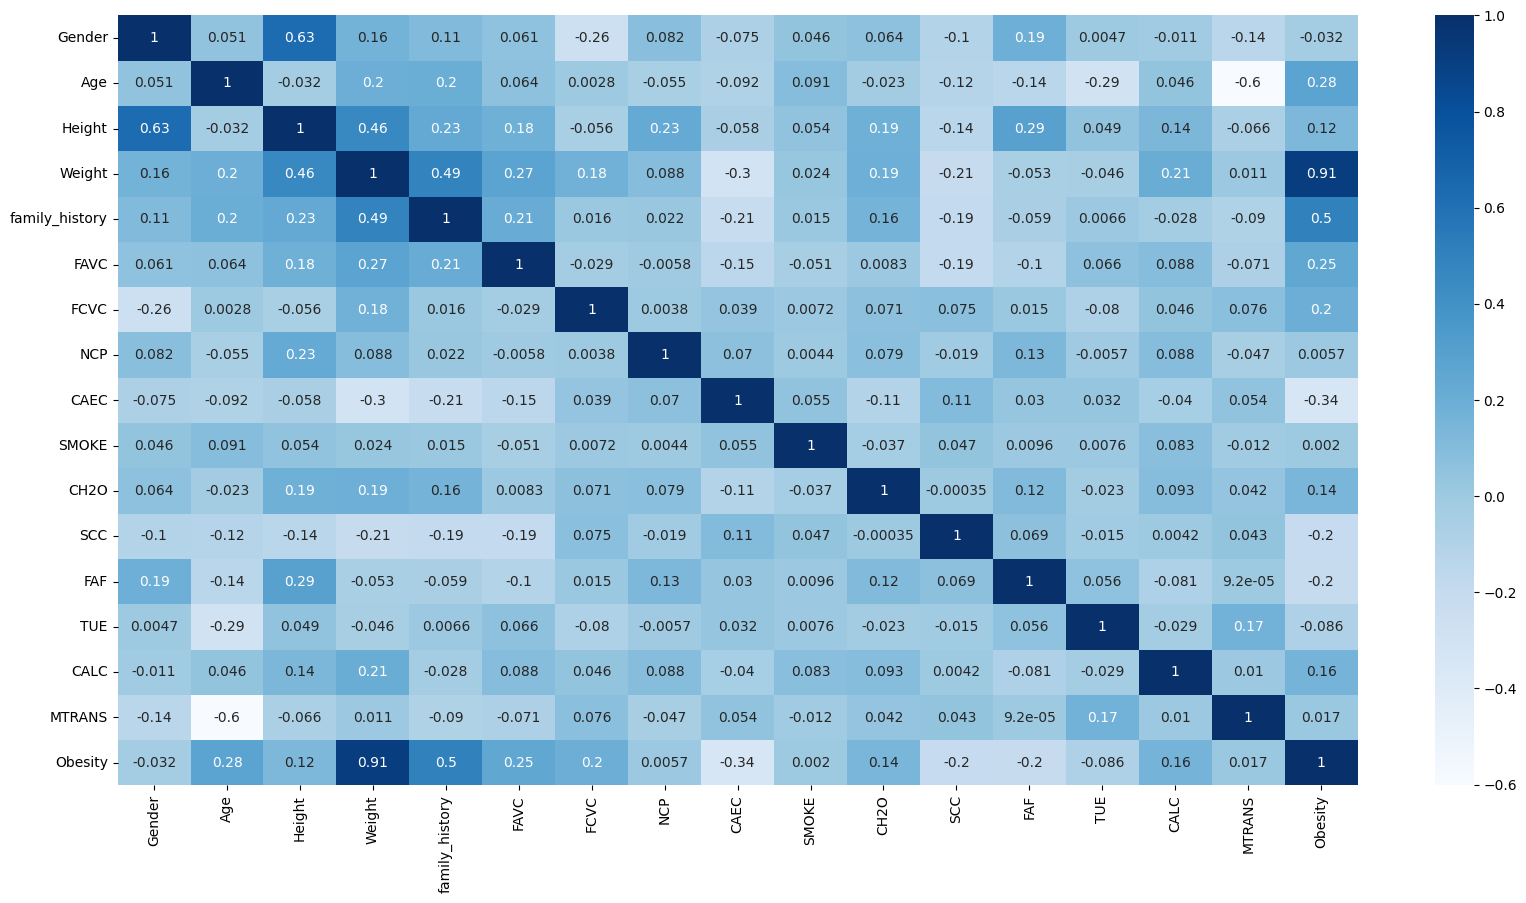

In [ ]:
corr = feature.corr(numeric_only=True)
plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)

## 4.2 Dividindo o dataset em treino e teste

In [ ]:
SEED = 1561651
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=SEED)

In [ ]:
train_df.shape

(1669, 17)

In [ ]:
test_df.shape

(418, 17)

In [ ]:
train_df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
1671,Masculino,31.743821,1.677820,102.022057,Sim,Sim,Sempre,Duas,Às Vezes,Não,<1 L/dia,Não,3-4x/semana,0-2h/dia,Não Bebe,Transporte Público,Obesidade II
995,Masculino,22.869778,1.795311,89.868784,Sim,Sim,Às Vezes,Duas,Às Vezes,Não,1-2 L/dia,Não,Nenhuma,3-5h/dia,Às Vezes,Transporte Público,Sobrepeso II
463,Masculino,17.000000,1.800000,68.000000,Sim,Não,Às Vezes,Três,Às Vezes,Não,<1 L/dia,Não,3-4x/semana,3-5h/dia,Às Vezes,Transporte Público,Peso Normal
1609,Masculino,22.658572,1.784994,113.714521,Sim,Sim,Às Vezes,Três,Às Vezes,Não,1-2 L/dia,Não,1-2x/semana,0-2h/dia,Às Vezes,Transporte Público,Obesidade II
1744,Masculino,25.550506,1.772740,114.254278,Sim,Sim,Às Vezes,Três,Às Vezes,Não,1-2 L/dia,Não,1-2x/semana,0-2h/dia,Às Vezes,Transporte Público,Obesidade II


# 5. Pipeline

## 5.1 Criando as classes

In [ ]:
class MinMax(BaseEstimator, TransformerMixin):
    def __init__(self, min_max_scaler=['Age', 'Height', 'Weight']):
        self.min_max_scaler = min_max_scaler
        self.scaler = MinMaxScaler()

    def fit(self, df, y=None):
        self.scaler.fit(df[self.min_max_scaler])
        return self

    def transform(self, df):
        df = df.copy()
        df[self.min_max_scaler] = self.scaler.transform(df[self.min_max_scaler])
        return df

In [ ]:
class OneHotEncodingNames(BaseEstimator, TransformerMixin):
    def __init__(self, OneHotEncoding=['Gender', 'family_history', 'FAVC','SMOKE','SCC','MTRANS']):
        self.OneHotEncoding = OneHotEncoding
        self.encoder = OneHotEncoder(sparse_output=False)

    def fit(self, df, y=None):
        self.encoder.fit(df[self.OneHotEncoding])
        return self

    def transform(self, df):
        df = df.copy()
        encoded = self.encoder.transform(df[self.OneHotEncoding])
        feature_names = self.encoder.get_feature_names_out(self.OneHotEncoding)
        df_encoded = pd.DataFrame(encoded, columns=feature_names, index=df.index)
        df_rest = df.drop(columns=self.OneHotEncoding)
        return pd.concat([df_encoded, df_rest], axis=1)

In [ ]:
class OrdinalFeature(BaseEstimator, TransformerMixin):
    def __init__(self, ordinal_feature=None):
        if ordinal_feature is None:
            self.ordinal_feature = ['FCVC', 'NCP', 'CAEC', 'CH2O', 'FAF', 'TUE', 'CALC', 'Obesity']
        else:
            self.ordinal_feature = ordinal_feature
        self.ordinal_encoder = OrdinalEncoder()

    def fit(self, df, y=None):
        self.ordinal_encoder.fit(df[self.ordinal_feature])
        return self

    def transform(self, df):
        df = df.copy()
        df[self.ordinal_feature] = self.ordinal_encoder.transform(df[self.ordinal_feature])
        return df

In [ ]:
class Oversample(BaseEstimator, TransformerMixin):
    def __init__(self, target='Obesity'):
        self.target = target

    def fit(self, df, y=None):
        return self

    def transform(self, df):
        if self.target in df.columns:
            oversample = SMOTE(sampling_strategy='not majority')
            X = df.drop(columns=[self.target])
            y = df[self.target]
            X_bal, y_bal = oversample.fit_resample(X, y)
            df_bal = pd.concat([pd.DataFrame(X_bal, columns=X.columns),
                                pd.DataFrame(y_bal, columns=[self.target])],
                               axis=1)
            return df_bal
        else:
            print(f"A coluna target '{self.target}' não está no DataFrame")
            return df

## 5.2 Passando os dados pelo pipeline

In [ ]:
def pipeline(df):

    pipeline = Pipeline([
        ('OneHotEncoding', OneHotEncodingNames()),
        ('ordinal_feature', OrdinalFeature()),
        ('min_max_scaler', MinMax()),
        ('oversample', Oversample())
    ])
    df_pipeline = pipeline.fit_transform(df)
    return df_pipeline

In [ ]:
# Checando ordem dos valores categóricos de obesidade
encoder = OrdinalEncoder()
encoder.fit(train_df[['Obesity']])
print(encoder.categories_)

[array(['Abaixo do Peso', 'Obesidade I', 'Obesidade II', 'Obesidade III',
       'Peso Normal', 'Sobrepeso I', 'Sobrepeso II'], dtype=object)]


In [ ]:
train = pipeline(train_df)

In [ ]:
X_train, y_train = train.loc[:, train.columns != 'Obesity'], train['Obesity']

In [ ]:
test = pipeline(test_df)

In [ ]:
X_test, y_test= test.loc[:, test.columns != 'Obesity'], test['Obesity']

# 6. Modelos

## 6.1 Bases para rodar os modelos

In [ ]:
def roda_modelo(modelo, X_train, X_test, y_train, y_test, labels=None):
    modelo.fit(X_train, y_train)

    print(f"\n------------------------------ Resultados {modelo.__class__.__name__} ------------------------------\n")

    # Previsão de probabilidades
    prob_predic = modelo.predict_proba(X_test)

    # AUC para multiclasse
    try:
        auc = roc_auc_score(y_test, prob_predic, multi_class='ovr', average='macro')
        print(f"AUC (macro, OVR): {auc:.4f}")
    except ValueError as e:
        print(f"Erro ao calcular AUC: {e}")

    # Matriz de confusão
    print("\nMatriz de Confusão\n")
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_test,
        y_test,
        normalize='true',
        display_labels=labels,
        cmap=plt.cm.Blues,
        ax=ax
    )
    ax.set_title("Matriz de Confusão Normalizada", fontsize=16, fontweight="bold")
    ax.set_xlabel("Label Predita", fontsize=14)
    ax.set_ylabel("Label Verdadeira", fontsize=14)
    plt.grid(False)
    plt.show()

    # Relatório de classificação
    predicao = modelo.predict(X_test)
    print("\nClassification Report\n")
    print(classification_report(y_test, predicao, target_names=labels, zero_division=0))

In [ ]:
labels = [
    'Insufficient',
    'Norm',
    'Over I',
    'Over II',
    'Obesity1',
    'Obesity2',
    'Obesity3'
]

## 6.2 Regressão Logística

In [ ]:
modelo_logistico = LogisticRegression()


------------------------------ Resultados LogisticRegression ------------------------------

AUC (macro, OVR): 0.9340

Matriz de Confusão



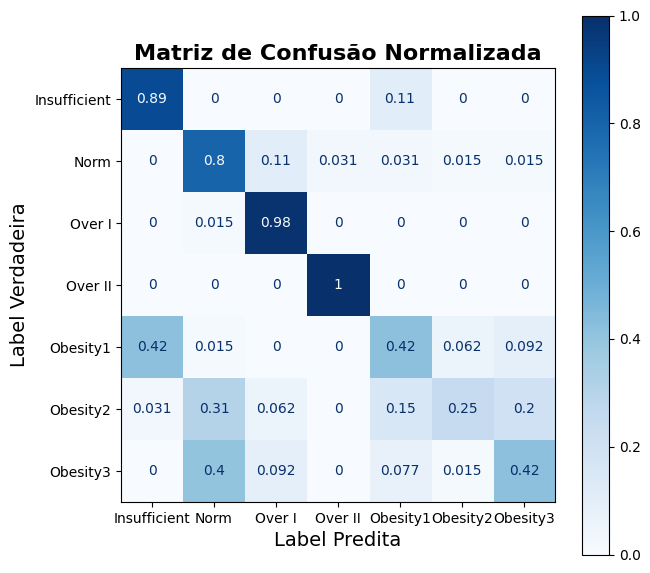


Classification Report

              precision    recall  f1-score   support

Insufficient       0.67      0.89      0.76        65
        Norm       0.52      0.80      0.63        65
      Over I       0.79      0.98      0.88        65
     Over II       0.97      1.00      0.98        65
    Obesity1       0.53      0.42      0.47        65
    Obesity2       0.73      0.25      0.37        65
    Obesity3       0.57      0.42      0.48        65

    accuracy                           0.68       455
   macro avg       0.68      0.68      0.65       455
weighted avg       0.68      0.68      0.65       455



In [ ]:
roda_modelo(modelo_logistico, X_train, X_test, y_train, y_test, labels=labels)

## 6.3 Árvore de Decisões

In [ ]:
modelo_tree = DecisionTreeClassifier()


------------------------------ Resultados DecisionTreeClassifier ------------------------------

AUC (macro, OVR): 0.8500

Matriz de Confusão



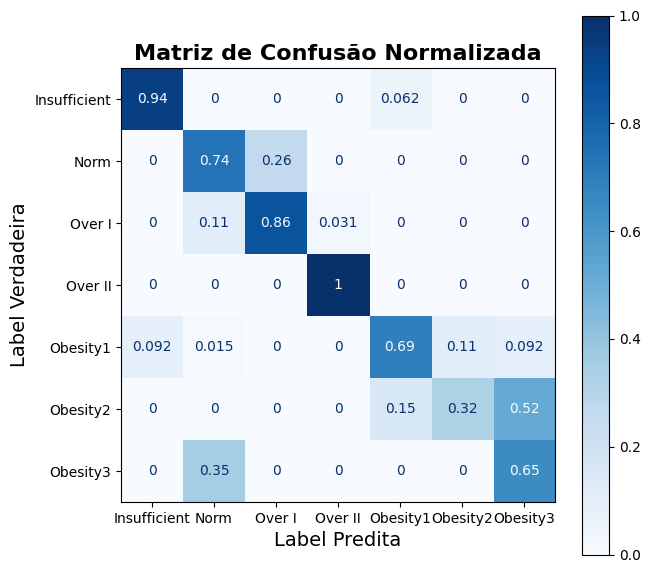


Classification Report

              precision    recall  f1-score   support

Insufficient       0.91      0.94      0.92        65
        Norm       0.61      0.74      0.67        65
      Over I       0.77      0.86      0.81        65
     Over II       0.97      1.00      0.98        65
    Obesity1       0.76      0.69      0.73        65
    Obesity2       0.75      0.32      0.45        65
    Obesity3       0.51      0.65      0.57        65

    accuracy                           0.74       455
   macro avg       0.75      0.74      0.73       455
weighted avg       0.75      0.74      0.73       455



In [ ]:
roda_modelo(modelo_tree, X_train, X_test, y_train, y_test, labels=labels)

## 6.4 Random Forest

In [ ]:
modelo_forest = RandomForestClassifier()


------------------------------ Resultados RandomForestClassifier ------------------------------

AUC (macro, OVR): 0.9768

Matriz de Confusão



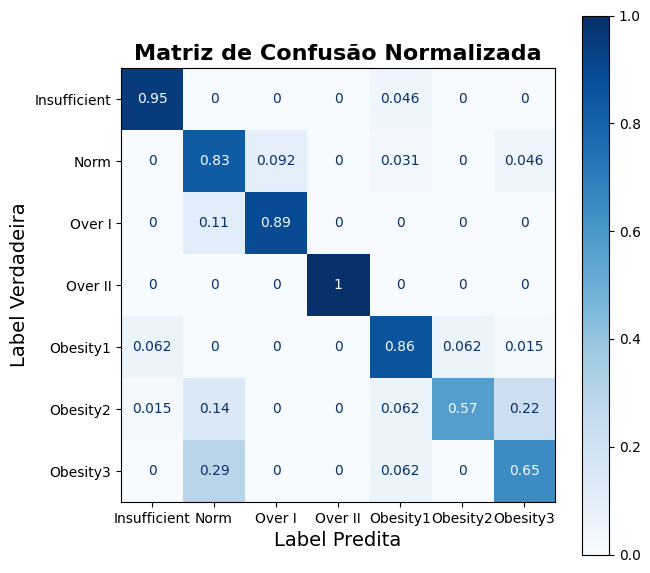


Classification Report

              precision    recall  f1-score   support

Insufficient       0.93      0.95      0.94        65
        Norm       0.61      0.83      0.70        65
      Over I       0.91      0.89      0.90        65
     Over II       1.00      1.00      1.00        65
    Obesity1       0.81      0.86      0.84        65
    Obesity2       0.90      0.57      0.70        65
    Obesity3       0.70      0.65      0.67        65

    accuracy                           0.82       455
   macro avg       0.84      0.82      0.82       455
weighted avg       0.84      0.82      0.82       455



In [ ]:
roda_modelo(modelo_forest, X_train, X_test, y_train, y_test, labels=labels)

## 6.5 XGB

In [ ]:
modelo_xgb = GradientBoostingClassifier()


------------------------------ Resultados GradientBoostingClassifier ------------------------------

AUC (macro, OVR): 0.9697

Matriz de Confusão



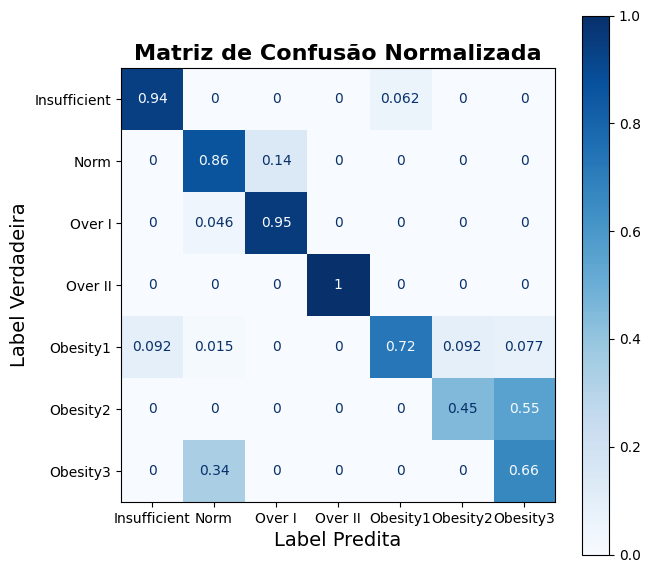


Classification Report

              precision    recall  f1-score   support

Insufficient       0.91      0.94      0.92        65
        Norm       0.68      0.86      0.76        65
      Over I       0.87      0.95      0.91        65
     Over II       1.00      1.00      1.00        65
    Obesity1       0.92      0.72      0.81        65
    Obesity2       0.83      0.45      0.58        65
    Obesity3       0.51      0.66      0.58        65

    accuracy                           0.80       455
   macro avg       0.82      0.80      0.80       455
weighted avg       0.82      0.80      0.80       455



In [ ]:
roda_modelo(modelo_xgb, X_train, X_test, y_train, y_test, labels=labels)

## 6.6 Exportando o modelo escolhido

In [ ]:
# Exportando modelo Random Forest
joblib.dump(modelo_forest, 'forest.joblib')

['forest.joblib']